# Analysis of the feature importance of the baseline models - with proper handling of missing values


Analyze the importance of the features in the baseline models to try to explain the models.
Use this information to improve the features of the models.

In [1]:
import core.constants as c
from core.feature_importance import (
    load_trained_models_and_results,
    load_dataset,
    compute_feature_importances_for_models,
    plot_feature_importances_by_model,
    plot_feature_vs_target_grid,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
results, trained_models = load_trained_models_and_results(c.RICKD_BASELINE_RESULTS_SUMMARY_V4)

In [3]:
X_train, X_test, y_train, y_test = load_dataset(
    c.RICKD_BASELINE_X_TRAIN_FILE,
    c.RICKD_BASELINE_X_TEST_FILE,
    c.RICKD_BASELINE_Y_TRAIN_FILE,
    c.RICKD_BASELINE_Y_TEST_FILE,
)

selected_cols = [
    # "speed_r",
    "age",
    "Height",
    "Weight",
    #"YrsRunning",
    #"NumRaces",
    "l_step_width",
    "l_stride_rate",
    "l_stride_length",
    "l_swing_time",
    "l_stance_time",
    "l_pelvis_peak_drop_angle",
    "l_pelvis_drop_excursion",
    "l_ankle_df_peak_angle",
    "l_ankle_eve_peak_angle",
    "l_ankle_eve_percent_stance",
    "l_ankle_eve_excursion",
    "l_ankle_rot_peak_angle",
    "l_ankle_rot_excursion",
    "l_knee_flex_peak_angle",
    "l_knee_add_peak_angle",
    "l_knee_add_excursion",
    "l_knee_abd_peak_angle",
    "l_knee_abd_excursion",
    "l_knee_rot_peak_angle",
    "l_knee_rot_excursion",
    "l_hip_ext_peak_angle",
    "l_hip_add_peak_angle",
    "l_hip_add_excursion",
    "l_hip_rot_peak_angle",
    "l_hip_rot_excursion",
    "l_foot_prog_angle",
    "l_foot_ang_at_hs",
    "l_mhw_exc_from_to",
    "l_ankle_eve_peak_vel",
    "l_ankle_rot_peak_vel",
    "l_knee_abd_peak_vel",
    "l_knee_add_peak_vel",
    "l_hip_abd_peak_vel",
    "l_knee_rot_peak_vel",
    "l_hip_rot_peak_vel",
    "l_pronation_onset",
    "l_pronation_offset",
    "l_peak_hip_add_velocity",
    "l_peak_pelvic_drop_velocity",
    "l_vertical_oscillation",
    "r_step_width",
    "r_stride_rate",
    "r_stride_length",
    "r_swing_time",
    "r_stance_time",
    "r_pelvis_peak_drop_angle",
    "r_pelvis_drop_excursion",
    "r_ankle_df_peak_angle",
    "r_ankle_eve_peak_angle",
    "r_ankle_eve_percent_stance",
    "r_ankle_eve_excursion",
    "r_ankle_rot_peak_angle",
    "r_ankle_rot_excursion",
    "r_knee_flex_peak_angle",
    "r_knee_add_peak_angle",
    "r_knee_add_excursion",
    "r_knee_abd_peak_angle",
    "r_knee_abd_excursion",
    "r_knee_rot_peak_angle",
    "r_knee_rot_excursion",
    "r_hip_ext_peak_angle",
    "r_hip_add_peak_angle",
    "r_hip_add_excursion",
    "r_hip_rot_peak_angle",
    "r_hip_rot_excursion",
    "r_foot_prog_angle",
    "r_foot_ang_at_hs",
    "r_mhw_exc_from_to",
    "r_ankle_eve_peak_vel",
    "r_ankle_rot_peak_vel",
    "r_knee_abd_peak_vel",
    "r_knee_add_peak_vel",
    "r_hip_abd_peak_vel",
    "r_knee_rot_peak_vel",
    "r_hip_rot_peak_vel",
    "r_pronation_onset",
    "r_pronation_offset",
    "r_peak_hip_add_velocity",
    "r_peak_pelvic_drop_velocity",
    "r_vertical_oscillation",
    # "Gender_female",
    # "Gender_male",
    # "DominantLeg_ambidextrous",
    # "DominantLeg_left",
    # "DominantLeg_right",
    # "Level_competitive",
    # "Level_recreational",
]
X_train = X_train[selected_cols]
X_test = X_test[selected_cols]

In [4]:
all_feature_importance = compute_feature_importances_for_models(
    trained_models, X_test, y_test, random_state=RANDOM_STATE
)

Extracting feature importance for Logistic Regression...
Using coef_ for Logistic Regression...
Extracting feature importance for Random Forest...
Using feature_importances_ for Random Forest...
Extracting feature importance for XGBoost...
Using feature_importances_ for XGBoost...
Extracting feature importance for SVM...
Computing permutation importance for SVM...


## Feature Importance Visualization

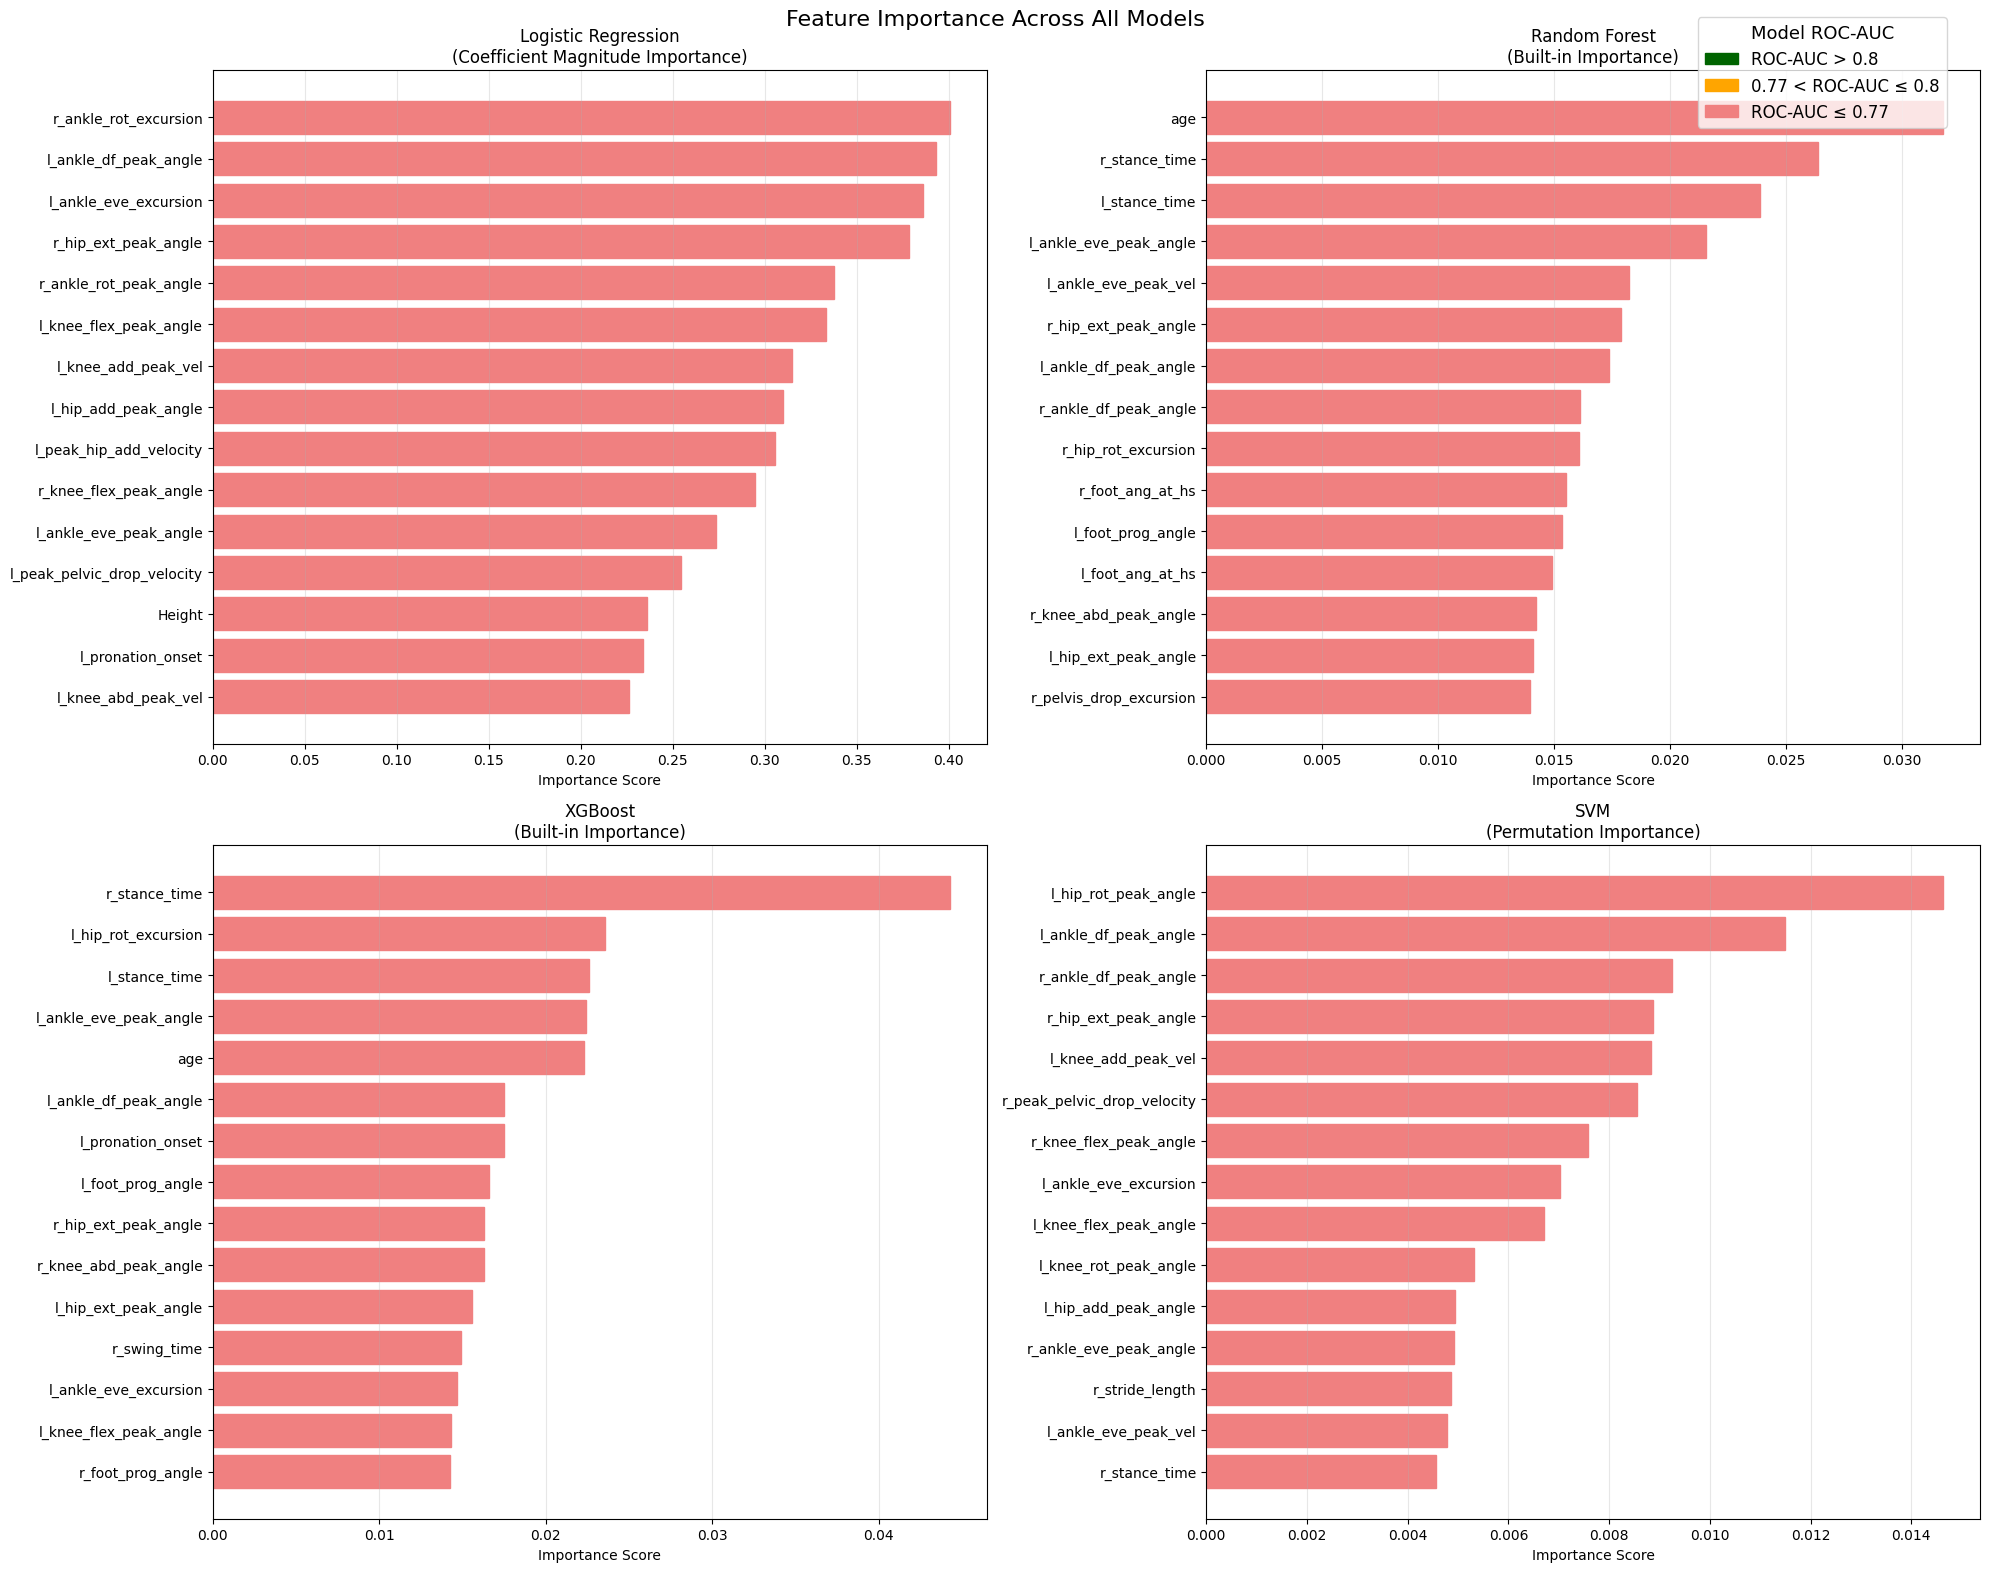

In [5]:
plot_feature_importances_by_model(all_feature_importance, results, top_n=15, figsize=(20, 16))

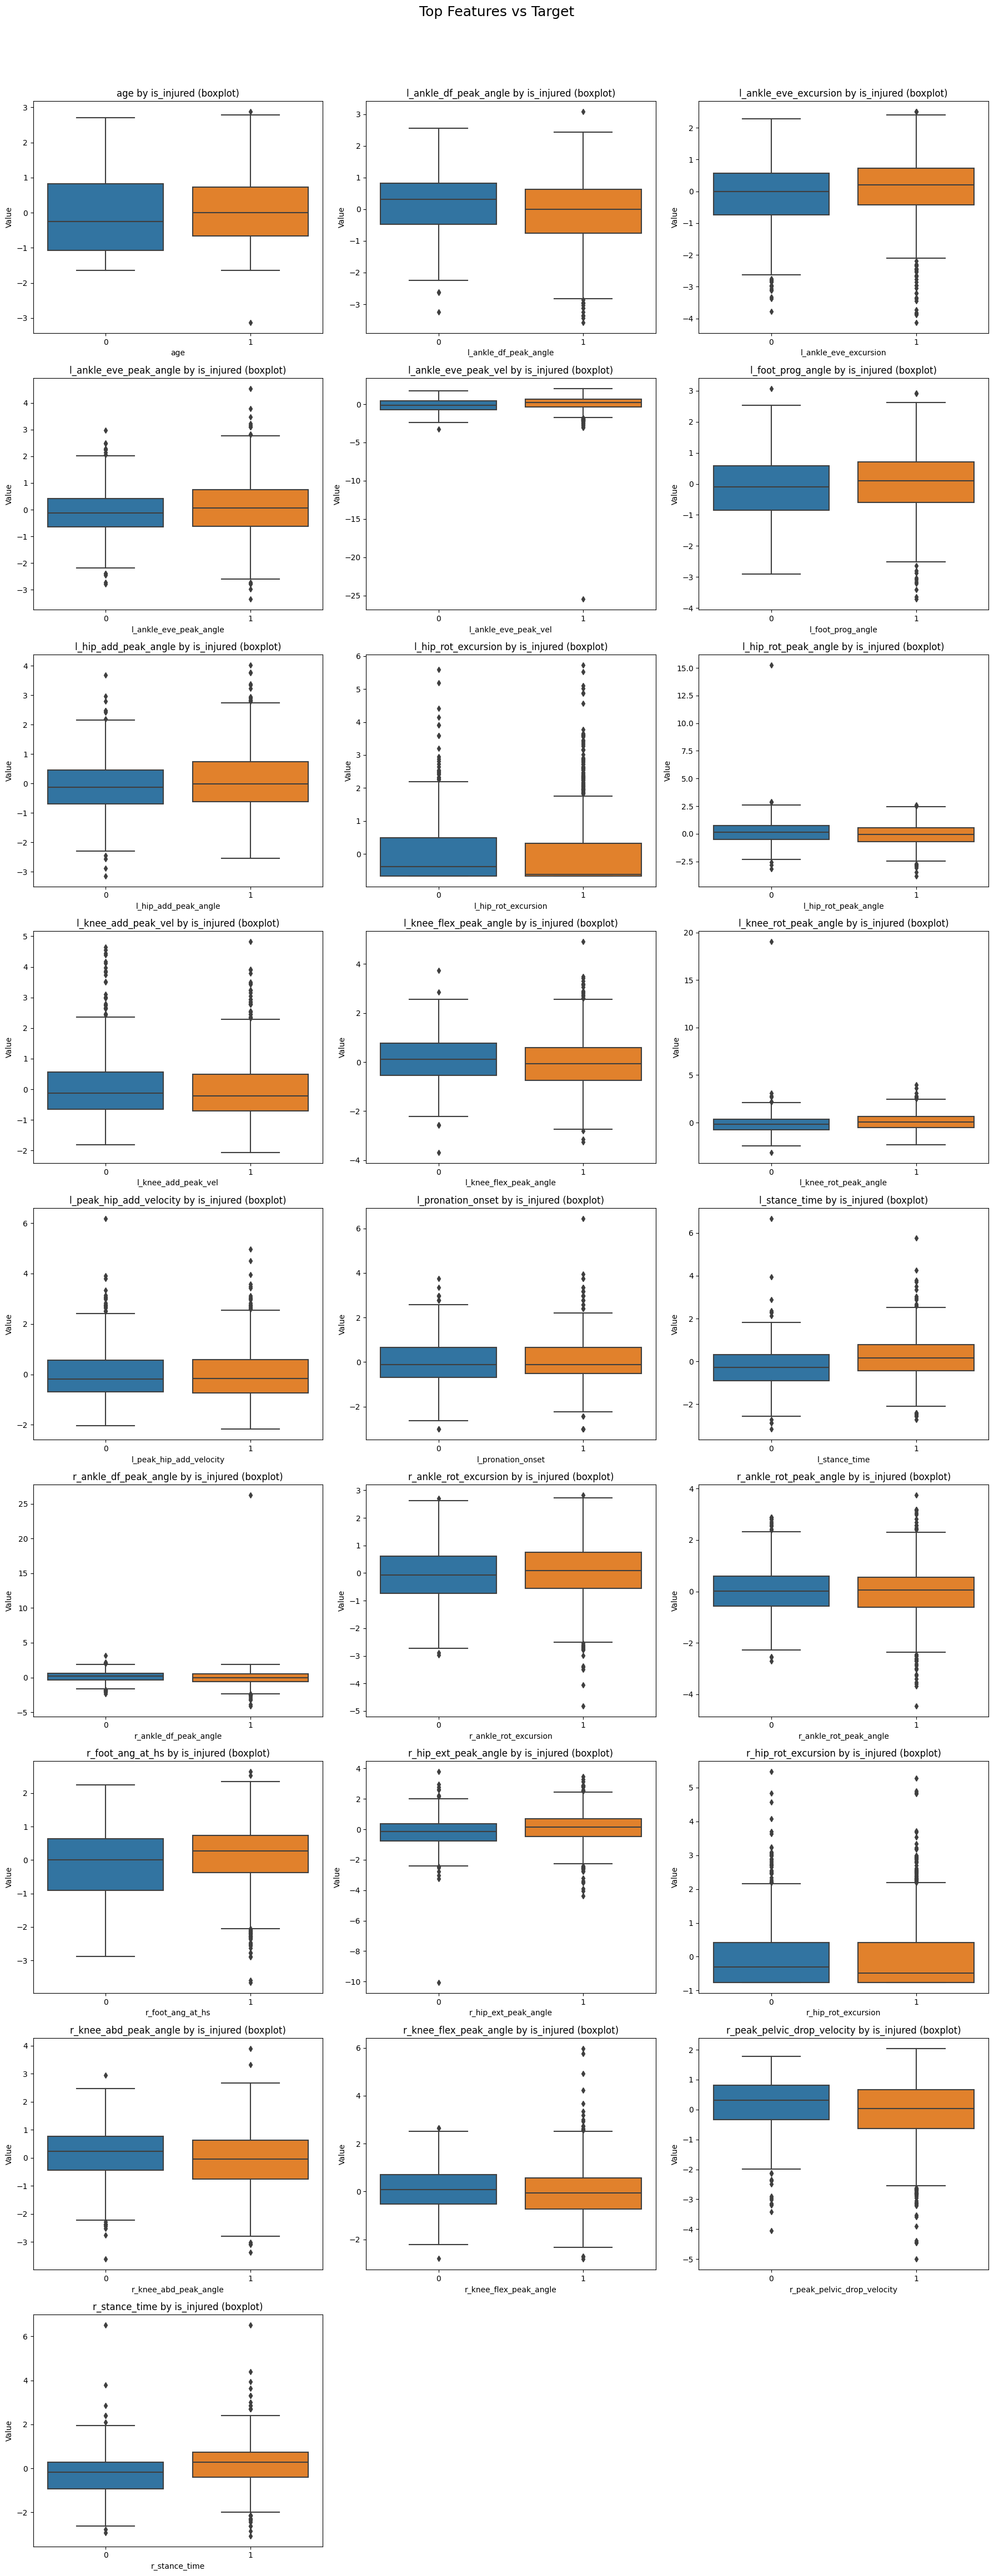

In [6]:
X = pd.read_csv(c.RICKD_BASELINE_X_FILE, index_col=0)
y = pd.read_csv(c.RICKD_BASELINE_Y_FILE, index_col=0)


# Collect top 10 features for each model based on importance
top_features_to_check = set()
for model_name, importance_df in all_feature_importance.items():
    top_features = importance_df.sort_values("importance", ascending=False).head(10)["feature"]
    top_features_to_check.update(top_features)

top_features_to_check = list(top_features_to_check)
top_features_to_check.sort()

plot_feature_vs_target_grid(
    X=X,
    y=y,
    features=top_features_to_check,
    target_col='is_injured',
    n_cols=3,
    figsize_per_cell=(6, 5),
)

In [7]:
for feature in list(top_features_to_check):
    print(feature)

age
l_ankle_df_peak_angle
l_ankle_eve_excursion
l_ankle_eve_peak_angle
l_ankle_eve_peak_vel
l_foot_prog_angle
l_hip_add_peak_angle
l_hip_rot_excursion
l_hip_rot_peak_angle
l_knee_add_peak_vel
l_knee_flex_peak_angle
l_knee_rot_peak_angle
l_peak_hip_add_velocity
l_pronation_onset
l_stance_time
r_ankle_df_peak_angle
r_ankle_rot_excursion
r_ankle_rot_peak_angle
r_foot_ang_at_hs
r_hip_ext_peak_angle
r_hip_rot_excursion
r_knee_abd_peak_angle
r_knee_flex_peak_angle
r_peak_pelvic_drop_velocity
r_stance_time
